# 06. Time Series Forecasting with ARMAX

Estimate a BestFit `ARMAX` model via BestFit `MaximumLikelihood`, then use `Predict` and residual diagnostics.

In [1]:
import pythonnet
pythonnet.load("netfx")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_donet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

from System import DateTime, Double
from System.Collections.Generic import List
from Numerics.Data import TimeSeries, TimeInterval
from RMC.BestFit.Model import ARMAX
from RMC.BestFit.Estimation import MaximumLikelihood, OptimizationMethod

def to_dotnet_list(values):
    l = List[Double]()
    for v in values:
        l.Add(float(v))
    return l

In [ ]:
# Generate synthetic data
rng = np.random.default_rng(14)
n = 120
t = np.arange(n)
flow = 90 + 6*np.sin(2*np.pi*t/12) + 0.03*t + rng.normal(0, 2.5, n)

# Create TimeSeries and fit ARMAX(1,0,1) model
ts = TimeSeries(TimeInterval.OneMonth, DateTime(2000,1,1), to_dotnet_list(flow))
model = ARMAX(ts)
# 
model.AROrderP = 1
# 
model.DiffOrderD = 0
# 
model.MAOrderQ = 1
#
model.XOrderB = 0
model.IncludeIntercept = True
model.IncludeSeasonality = False
model.SetDefaultParameters()

# Estimate parameters using Maximum Likelihood Estimation
mle = MaximumLikelihood(model)
mle.Estimate()
p_hat = np.array([float(v) for v in mle.BestParameterSet.Values], dtype=float)

# Compute in-sample predictions, residuals, and RMSE
pred_tuple = model.Predict(convert_to_donet_array(p_hat)) # Returns a tuple of (predictions, standard errors)
pred = np.array(list(pred_tuple.Item1), dtype=float)
residuals = np.array(list(model.Residuals(convert_to_donet_array(p_hat))), dtype=float)
rmse = float(np.sqrt(np.mean(residuals**2)))

print('Estimated:', mle.IsEstimated)
print('Parameter vector:', np.round(p_hat, 5))
print('In-sample residual RMSE:', round(rmse, 3))

Estimated: True
Parameter vector: [91.27492  0.15529  0.39729  3.94965]
In-sample residual RMSE: 3.952


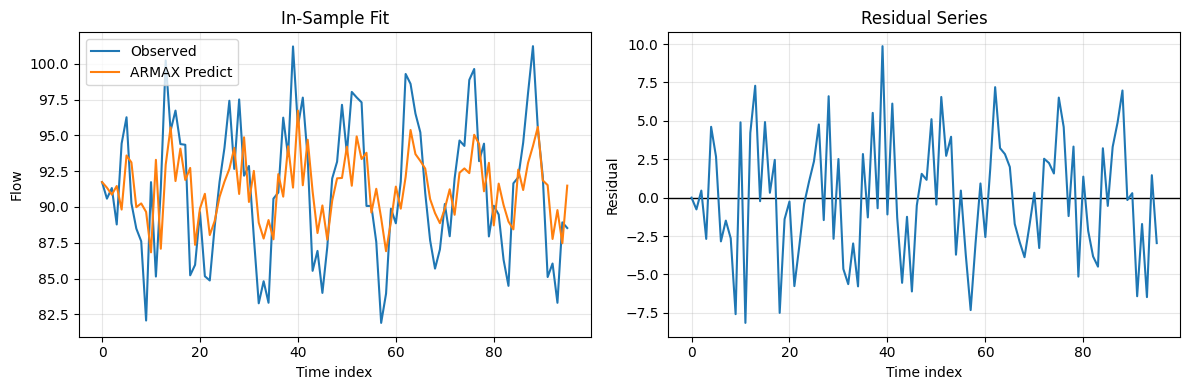

In [4]:
# Plot observed vs predicted values
fig, ax = plt.subplots(1,2, figsize=(12,4))
ix = np.arange(len(pred))
ax[0].plot(ix, flow[:len(pred)], label='Observed')
ax[0].plot(ix, pred, label='ARMAX Predict')
ax[0].set_title('In-Sample Fit')
ax[0].set_xlabel('Time index')
ax[0].set_ylabel('Flow')
ax[0].grid(alpha=0.3)
ax[0].legend()

# Plot residuals
ax[1].axhline(0.0, color='black', lw=1)
ax[1].plot(np.arange(len(resid)), resid)
ax[1].set_title('Residual Series')
ax[1].set_xlabel('Time index')
ax[1].set_ylabel('Residual')
ax[1].grid(alpha=0.3)

plt.tight_layout()

## Summary

This is a BestFit-native ARMAX workflow using model estimation, prediction, and residual evaluation.

## Exercises
Exercises:
1. Compare `(p,q)=(1,1)` vs `(2,1)`.
2. Turn on differencing for nonstationary variants.
3. Add external covariates and nonzero `XOrderB`.